# Human Activity Recognition (HAR) - Task 1: Exploratory Data Analysis (EDA)

This notebook covers EDA for the UCI-HAR dataset, including waveform visualization, static vs dynamic activity analysis, PCA visualizations, TSFEL feature extraction, and correlation analysis.

## 1. Load and Preprocess UCI-HAR Dataset

Load the raw accelerometer data from the inertial_signals folder, run CombineScript.py and MakeDataset.py, and prepare train, test, and validation sets focusing on the first 500 samples per activity.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns


In [2]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Correct way to load UCI-HAR Combined dataset
def load_har_combined_data(base_dir):
    data = []
    for split in ['Train', 'Test']:
        split_dir = os.path.join(base_dir, split)
        for activity in os.listdir(split_dir):
            activity_dir = os.path.join(split_dir, activity)
            if not os.path.isdir(activity_dir):
                continue
            for csv_file in os.listdir(activity_dir):
                if not csv_file.endswith('.csv'):
                    continue
                file_path = os.path.join(activity_dir, csv_file)
                arr = np.loadtxt(file_path, delimiter=',', skiprows=1)  # Skip header row
                # Only use first 500 samples (10 seconds at 50Hz)
                arr = arr[100:600, :] if arr.shape[0] >= 500 else arr
                data.append({'acc_x': arr[:,0], 'acc_y': arr[:,1], 'acc_z': arr[:,2], 'activity': activity, 'subject': csv_file.replace('.csv','')})
    return pd.DataFrame(data)

combined_path = os.path.join('..\\human+activity+recognition+using+smartphones', 'Combined')
df = load_har_combined_data(combined_path)
print('Loaded HAR Combined dataset shape:', df.shape)
df.head()

Loaded HAR Combined dataset shape: (180, 5)


,acc_x,acc_y,acc_z,activity,subject
0,"[0.1881076, 0.1900625, 0.190812, 0.1894438, 0....","[0.7867169, 0.7862243, 0.7869899, 0.7897924, 0...","[0.5719042, 0.5730728, 0.5735939, 0.5756323, 0...",LAYING,Subject_1
1,"[0.2445142, 0.2446238, 0.2455519, 0.2460483, 0...","[0.9502907, 0.9477933, 0.949285, 0.952067, 0.9...","[0.1741417, 0.1760255, 0.1804649, 0.1804769, 0...",LAYING,Subject_11
2,"[0.1797785, 0.1696251, 0.1648379, 0.1675232, 0...","[0.5703901, 0.5697411, 0.5743193, 0.5743597, 0...","[0.7951251, 0.7993438, 0.7988303, 0.7977074, 0...",LAYING,Subject_14
3,"[0.1472669, 0.1469579, 0.1456987, 0.1477679, 0...","[0.9113154, 0.9063752, 0.9018037, 0.9048582, 0...","[0.3883553, 0.3962988, 0.4023564, 0.3931467, 0...",LAYING,Subject_15
4,"[0.2771875, 0.2739869, 0.2768942, 0.2803173, 0...","[0.4408688, 0.4379217, 0.4373589, 0.4393042, 0...","[0.8535804, 0.8549549, 0.8561807, 0.8555862, 0...",LAYING,Subject_16


## 2. Plot Waveforms for Each Activity Class

Visualize one sample waveform from each activity class to observe similarities and differences.

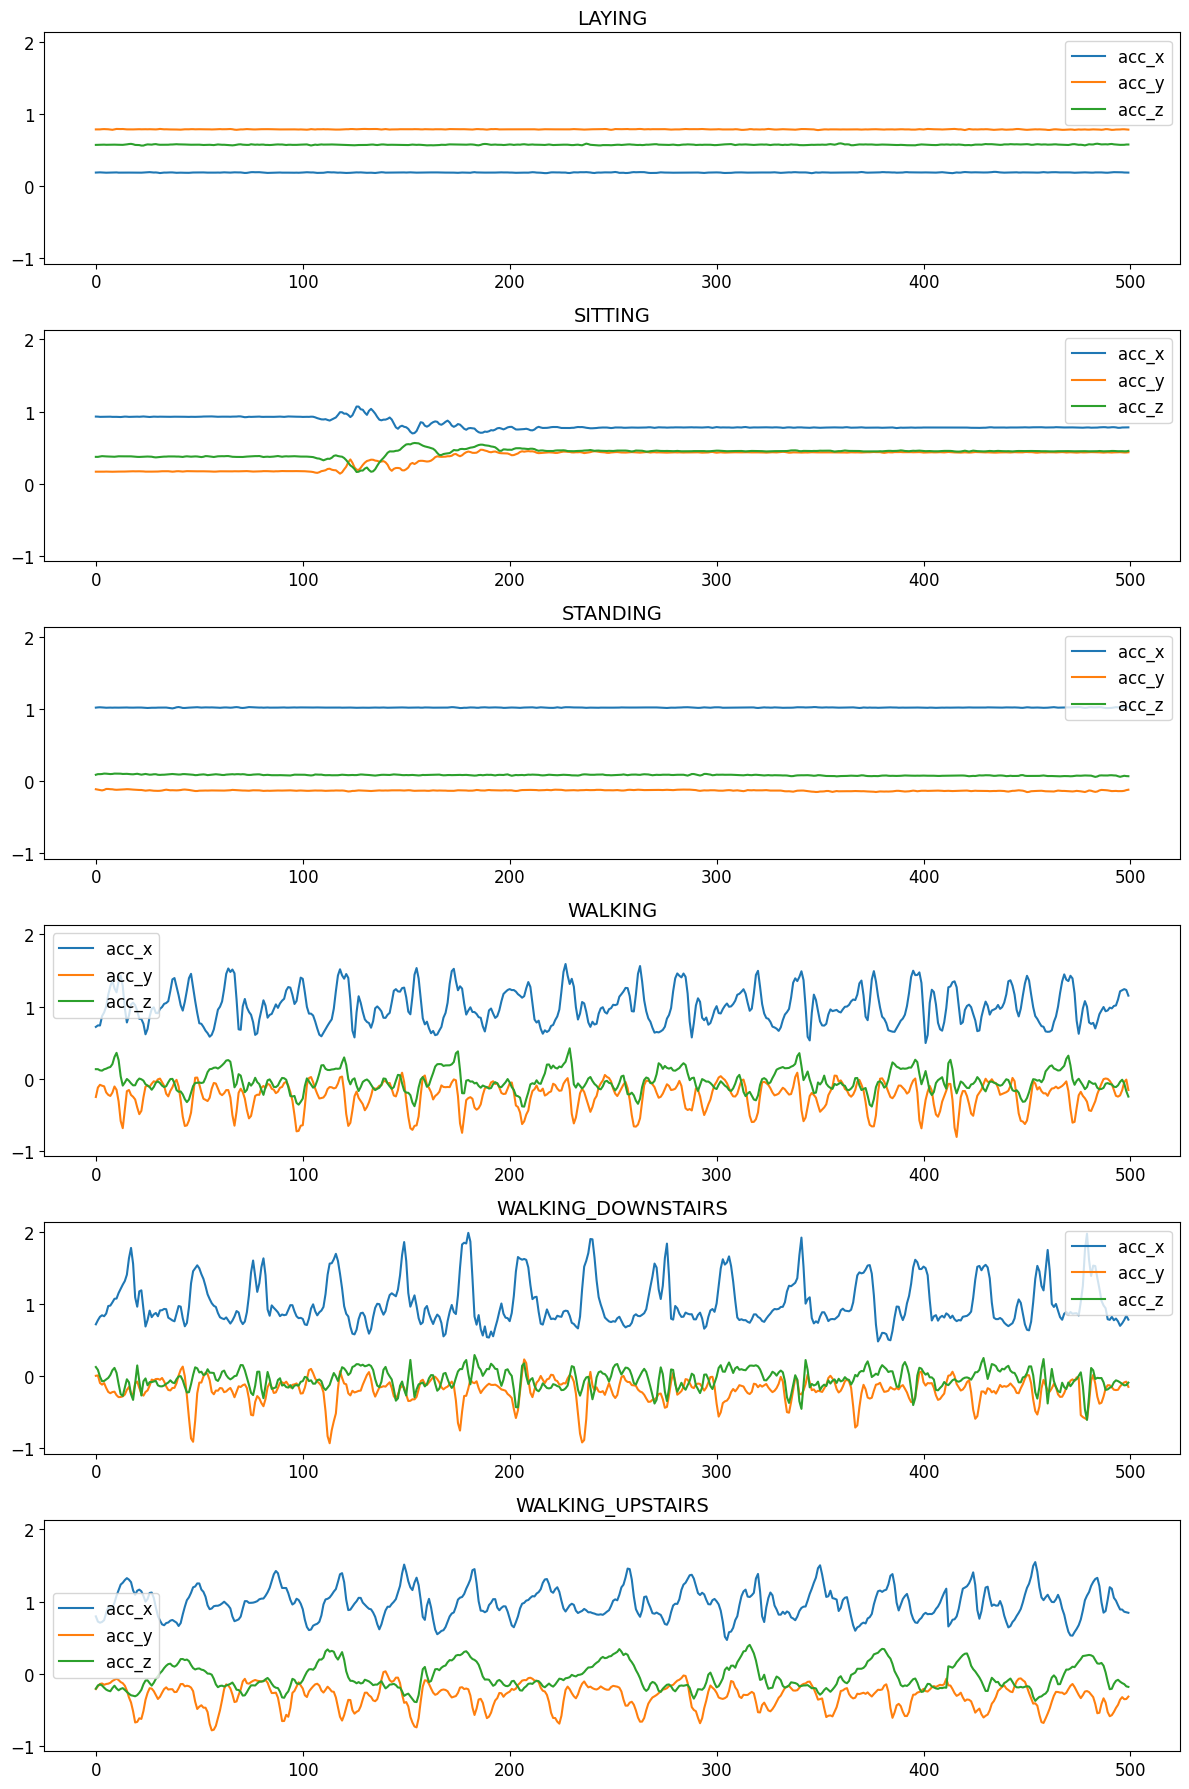

In [3]:
activity_classes = df['activity'].unique()
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(12, 3 * len(activity_classes)), sharey=True)
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    sample = df[df['activity'] == activity].iloc[0]
    acc_x = sample['acc_x']
    acc_y = sample['acc_y']
    acc_z = sample['acc_z']
    axes[i].plot(acc_x, label='acc_x')
    axes[i].plot(acc_y, label='acc_y')
    axes[i].plot(acc_z, label='acc_z')
    axes[i].set_title(activity, fontsize=14)
    axes[i].legend(fontsize=12)
    axes[i].tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

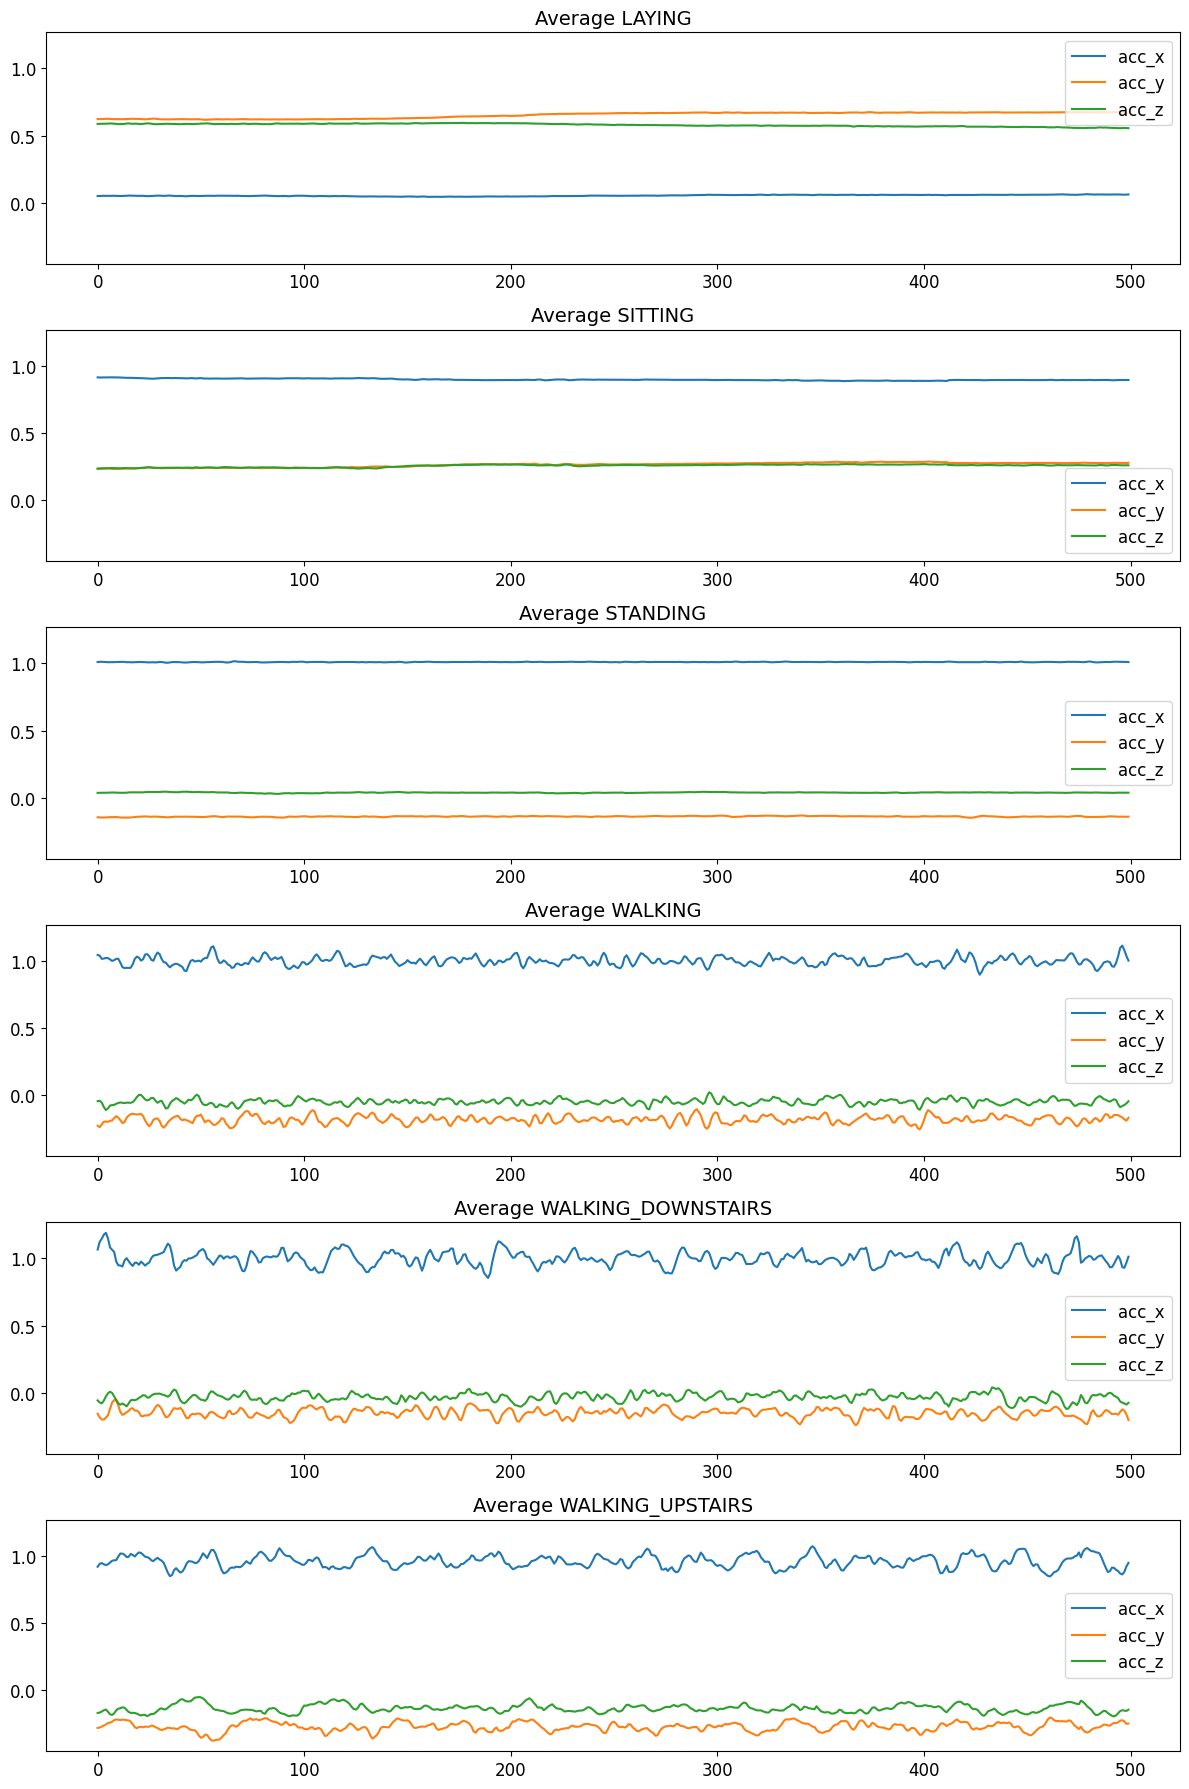

In [4]:
# plot the average signal for each activity
x_avg = df.groupby('activity')['acc_x'].apply(lambda x: np.mean(np.vstack(x), axis=0))
y_avg = df.groupby('activity')['acc_y'].apply(lambda x: np.mean(np.vstack(x), axis=0))
z_avg = df.groupby('activity')['acc_z'].apply(lambda x: np.mean(np.vstack(x), axis=0))
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(12, 3 * len(activity_classes)), sharey=True)
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    acc_x = x_avg[activity]
    acc_y = y_avg[activity]
    acc_z = z_avg[activity]
    axes[i].plot(acc_x, label='acc_x')
    axes[i].plot(acc_y, label='acc_y')
    axes[i].plot(acc_z, label='acc_z')
    axes[i].set_title(f'Average {activity}', fontsize=14)
    axes[i].legend(fontsize=12)
    axes[i].tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()


## 3. Analyze Linear Acceleration for Static vs Dynamic Activities

Compute and plot linear acceleration (acc_x^2 + acc_y^2 + acc_z^2) for each activity class to compare static and dynamic activities.

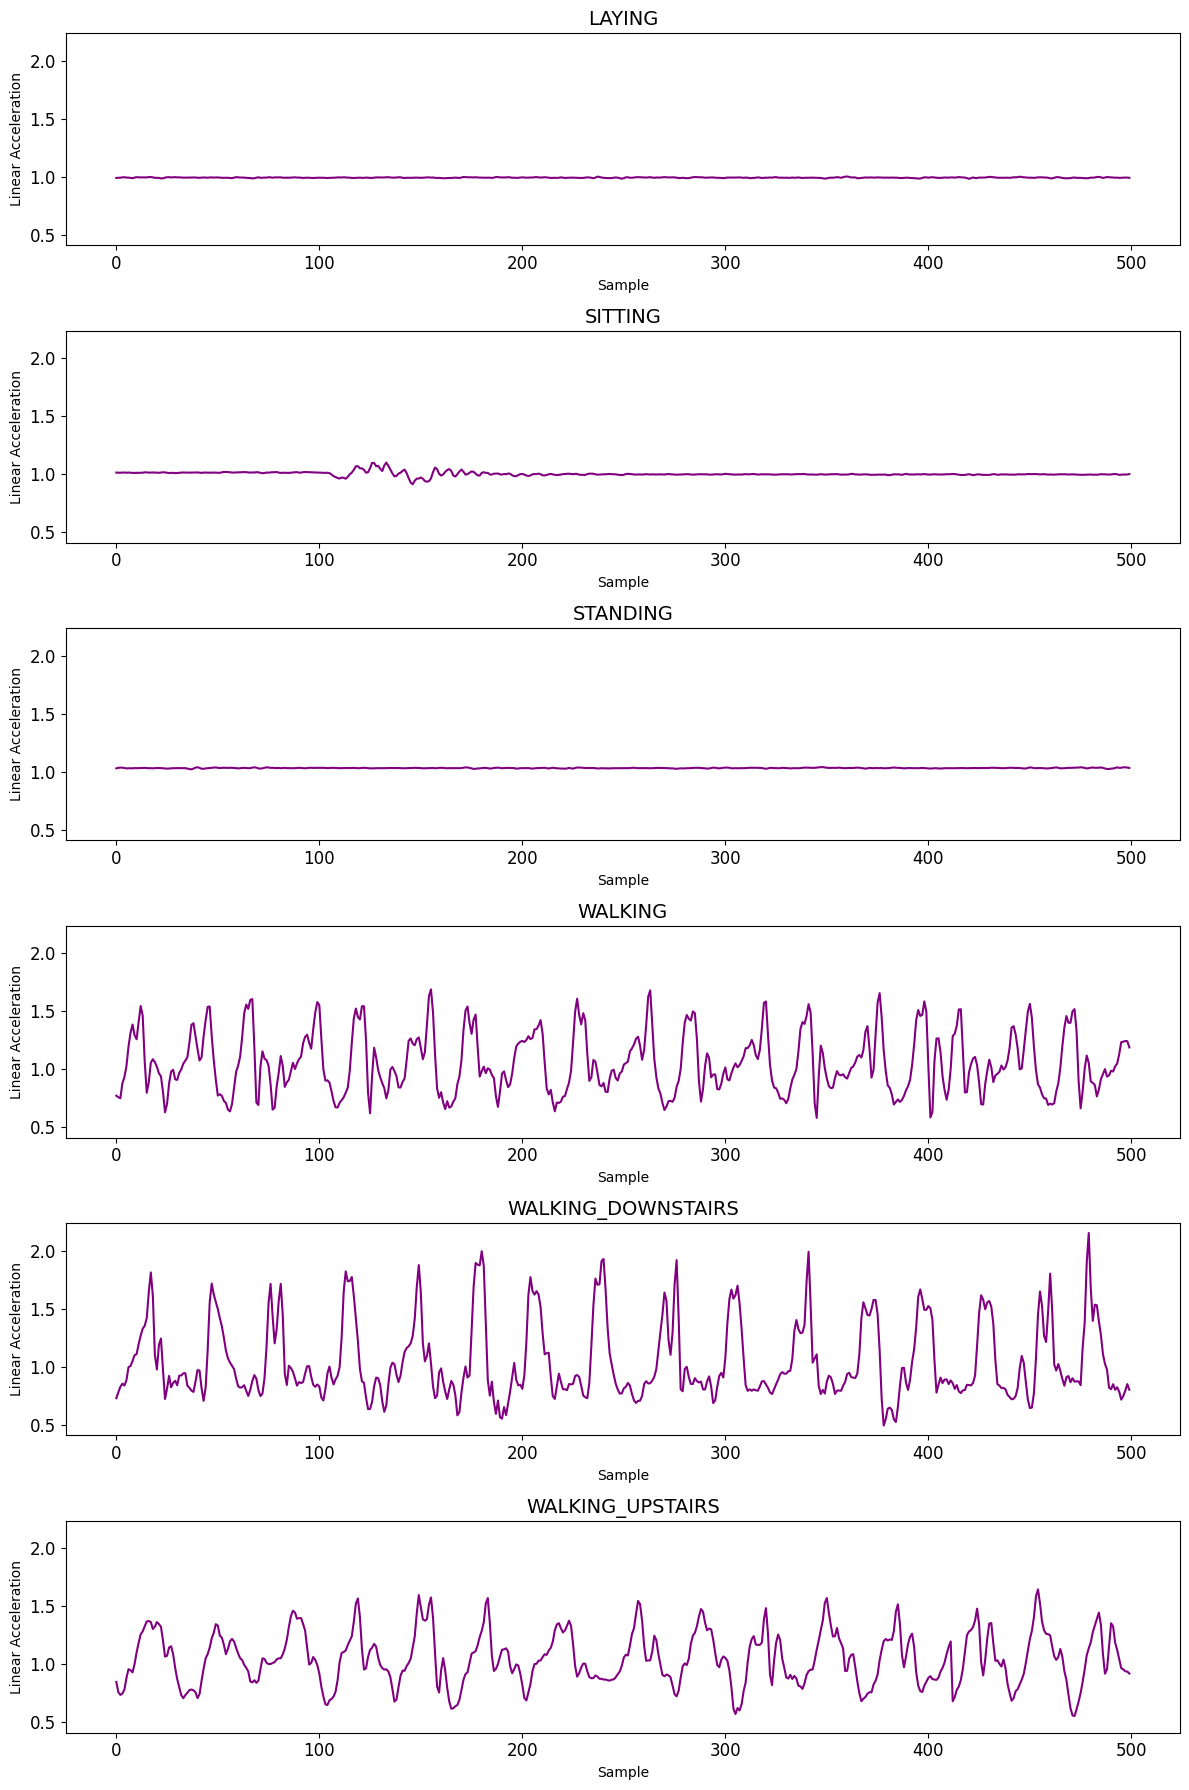

In [5]:
activity_classes = df['activity'].unique()
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(12, 3 * len(activity_classes)), sharey=True)
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    sample = df[df['activity'] == activity].iloc[0]
    acc_x = sample['acc_x']
    acc_y = sample['acc_y']
    acc_z = sample['acc_z']
    linear_acc = (acc_x**2 + acc_y**2 + acc_z**2)**0.5
    axes[i].plot(linear_acc, color='purple')
    axes[i].set_title(activity, fontsize=14)
    axes[i].set_xlabel('Sample')
    axes[i].set_ylabel('Linear Acceleration')
    axes[i].tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

## 4. PCA Visualization on Total Acceleration

Apply PCA on total acceleration to reduce to two features and plot a scatter plot for activity classes.

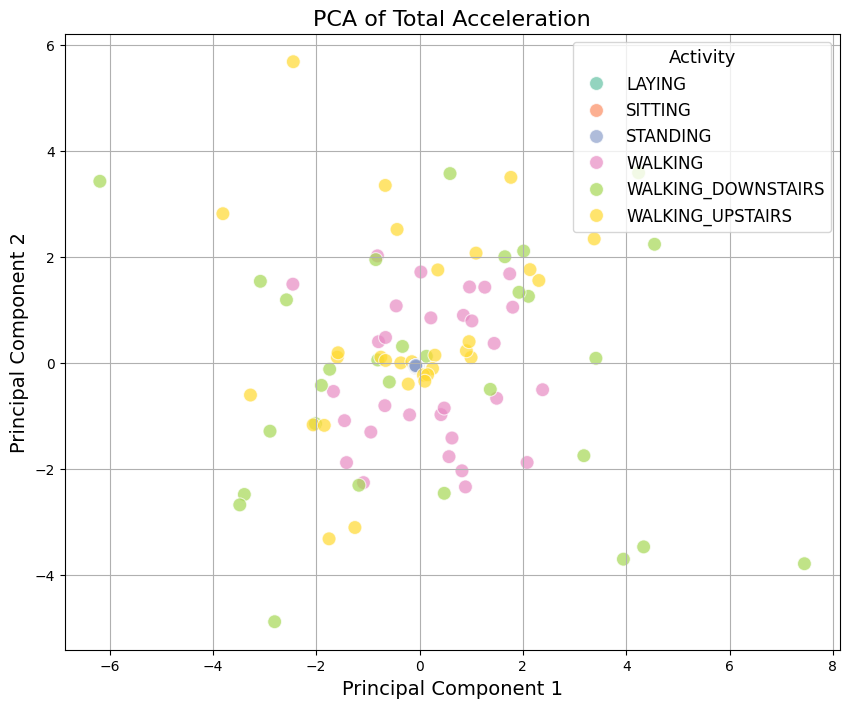

In [3]:
# Prepare total acceleration features for PCA
X_total_acc = []
y_labels = []
for idx, row in df.iterrows():
    acc_x = row['acc_x']
    acc_y = row['acc_y']
    acc_z = row['acc_z']
    total_acc = (acc_x**2 + acc_y**2 + acc_z**2)**0.5
    X_total_acc.append(total_acc)
    y_labels.append(row['activity'])
X_total_acc = np.array(X_total_acc)
df['total_acc'] = list(X_total_acc)
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_total_acc)

# Plot pcaa results
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_labels, palette='Set2', s=100, alpha=0.7)
plt.title('PCA of Total Acceleration', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.legend(title='Activity', fontsize=12, title_fontsize=13)
plt.grid(True)
plt.show()

 Unique activities are not separated well in PCA plot, indicating overlapping feature space.

## 5. Feature Extraction with TSFEL and PCA Visualization

Extract features using TSFEL, apply PCA to reduce to two features, and plot a scatter plot for activity classes.

- First we try pca on tsfel feature of total acceleration data

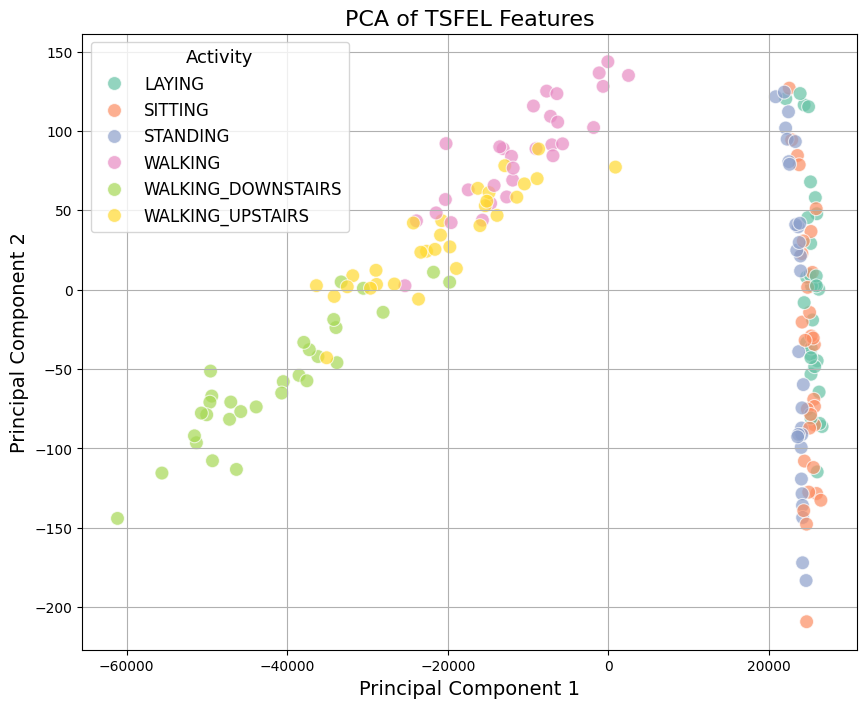

In [20]:
# Install TSFEL if not already installed
try:
    import tsfel
except ImportError:
    !pip install tsfel
    import tsfel

# Extract TSFEL features for each sample (using acc_x as example)
cfg = tsfel.get_features_by_domain()
ts_features = []
for idx, row in df.iterrows():
    tot = row['total_acc']
    features = tsfel.time_series_features_extractor(cfg, tot, verbose=0, fs=50)
    ts_features.append(features.values.flatten())
ts_features = np.array(ts_features)

# Apply PCA
pca = PCA(n_components=3)
ts_pca = pca.fit_transform(ts_features)


# Plot PCA results for four components
plt.figure(figsize=(10, 8))
sns.scatterplot(x=ts_pca[:, 0], y=ts_pca[:, 1], hue=y_labels, palette='Set2', s=100, alpha=0.7)
plt.title('PCA of TSFEL Features', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.legend(title='Activity', fontsize=12, title_fontsize=13)
plt.grid(True)
plt.show()

C:\Users\sun\AppData\Local\Temp\ipykernel_20844\564832779.py:4: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  scatter = ax.scatter(ts_pca[:, 0], ts_pca[:, 1], ts_pca[:, 2], c=pd.factorize(y_labels)[0], cmap='Set2', s=100, alpha=0.7)


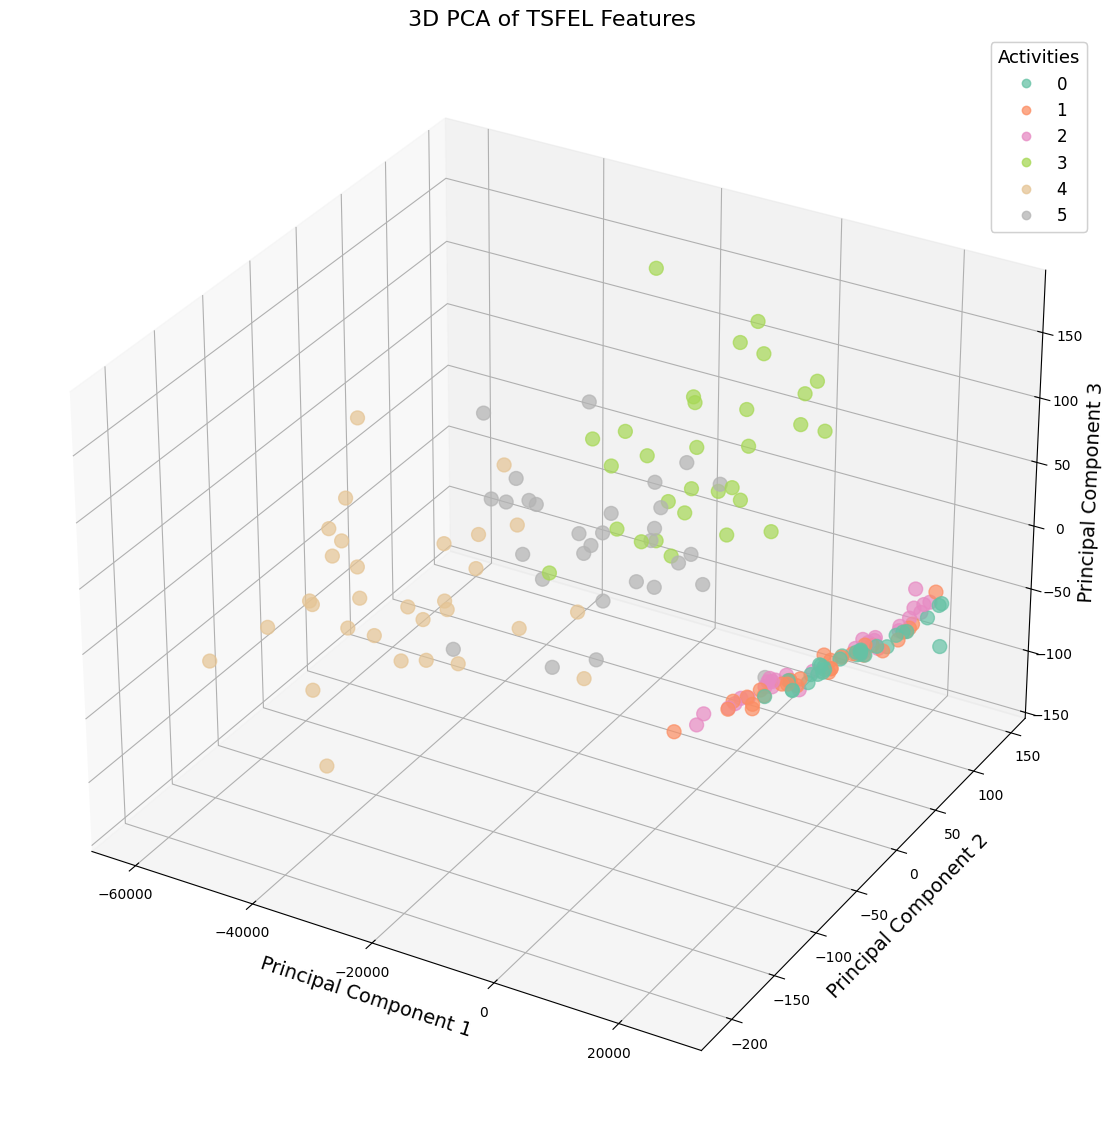

In [21]:
# plot 3d pca plot
fig = plt.figure(figsize=(14, 15))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(ts_pca[:, 0], ts_pca[:, 1], ts_pca[:, 2], c=pd.factorize(y_labels)[0], cmap='Set2', s=100, alpha=0.7)
ax.set_title('3D PCA of TSFEL Features', fontsize=16)
ax.set_xlabel('Principal Component 1', fontsize=14)
ax.set_ylabel('Principal Component 2', fontsize=14)
ax.set_zlabel('Principal Component 3', fontsize=14)
legend1 = ax.legend(*scatter.legend_elements(), title="Activities", fontsize=12, title_fontsize=13)
ax.add_artist(legend1)
plt.show()

We observe that pca on total acceleration features does not separate activities well for laying,standing,sitting.
- next we try pca on all tsfel features accx, accy, accz

C:\Users\sun\AppData\Local\Temp\ipykernel_20844\3752093655.py:14: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_20844\3752093655.py:14: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_20844\3752093655.py:14: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_20844\3752093655.py:14: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_20844\3752093655.py:14: UserWarning: Using default sampling frequency set in configuration file.
  fea

Extracted TSFEL features shape: (180, 135)
PCA output shape: (180, 3)


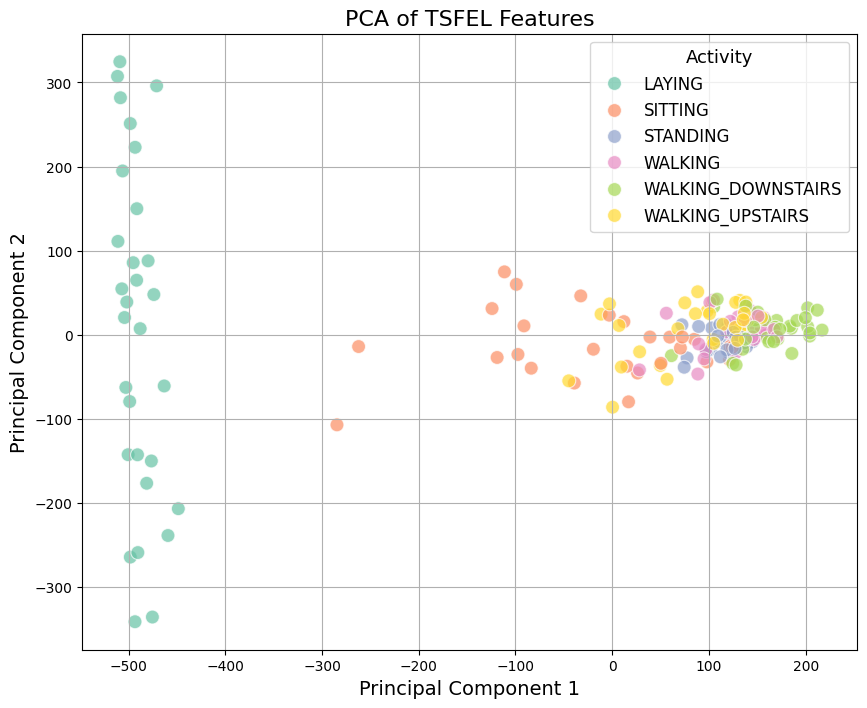

In [60]:

cfg = tsfel.get_features_by_domain()


selected_domains = ['statistical', 'temporal']
cfg_selected = {k: v for k, v in cfg.items() if k in selected_domains}

ts_features_1 = []

for sample in df[['acc_x', 'acc_y', 'acc_z']].values:
    # Extract features axis-wise and concatenate
    feat_list = []
    for axis in range(3):
        ts = sample[axis]
        feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
        feat_list.append(feat.values.flatten())
    combined_features = np.hstack(feat_list)
    ts_features_1.append(combined_features)

ts_features_1 = np.array(ts_features_1)
print(f"Extracted TSFEL features shape: {ts_features_1.shape}")

# Perform PCA to reduce to 2 features for visualization
pca = PCA(n_components=3)
ts_pca_1 = pca.fit_transform(ts_features_1)

print(f"PCA output shape: {ts_pca_1.shape}")

# Plot PCA results for four components
plt.figure(figsize=(10, 8))
sns.scatterplot(x=ts_pca_1[:, 0], y=ts_pca_1[:, 1], hue=y_labels, palette='Set2', s=100, alpha=0.7)
plt.title('PCA of TSFEL Features', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.legend(title='Activity', fontsize=12, title_fontsize=13)
plt.grid(True)
plt.show()


C:\Users\sun\AppData\Local\Temp\ipykernel_20844\2266492563.py:3: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  scatter = ax.scatter(ts_pca_1[:, 0], ts_pca_1[:, 1], ts_pca_1[:, 2], c=pd.factorize(y_labels)[0], cmap='Set2', s=100, alpha=0.7)


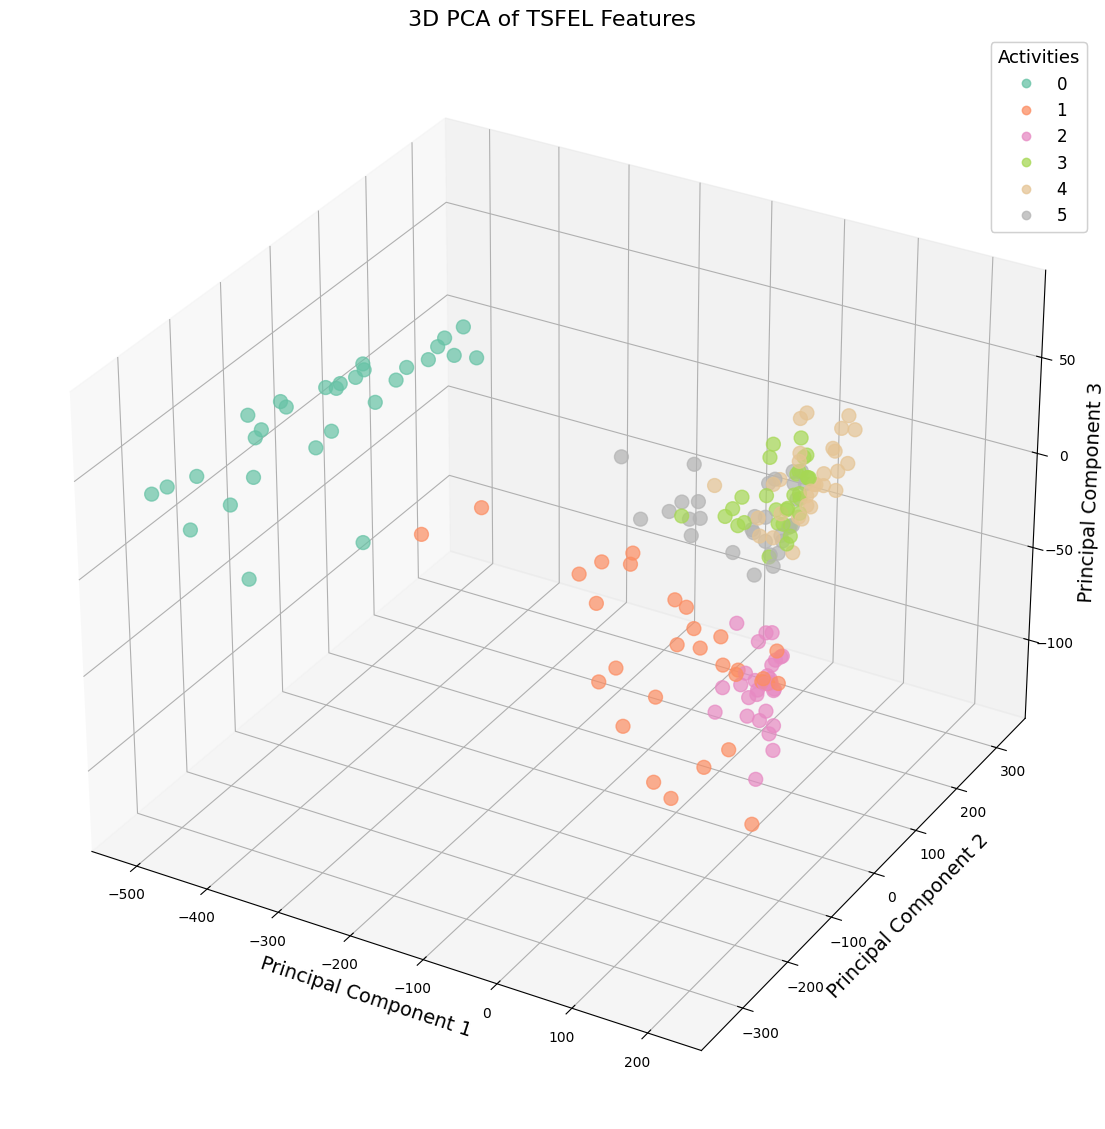

In [61]:
fig = plt.figure(figsize=(14, 15))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(ts_pca_1[:, 0], ts_pca_1[:, 1], ts_pca_1[:, 2], c=pd.factorize(y_labels)[0], cmap='Set2', s=100, alpha=0.7)
ax.set_title('3D PCA of TSFEL Features', fontsize=16)
ax.set_xlabel('Principal Component 1', fontsize=14)
ax.set_ylabel('Principal Component 2', fontsize=14)
ax.set_zlabel('Principal Component 3', fontsize=14)
legend1 = ax.legend(*scatter.legend_elements(), title="Activities", fontsize=12, title_fontsize=13)
ax.add_artist(legend1)
plt.show()

### Combining all three axes features improves separation of activity classes in PCA plot.


## 6. Correlation Analysis of TSFEL and Dataset Features

Calculate and visualize the correlation matrix for TSFEL and dataset features, identify highly correlated and redundant features.

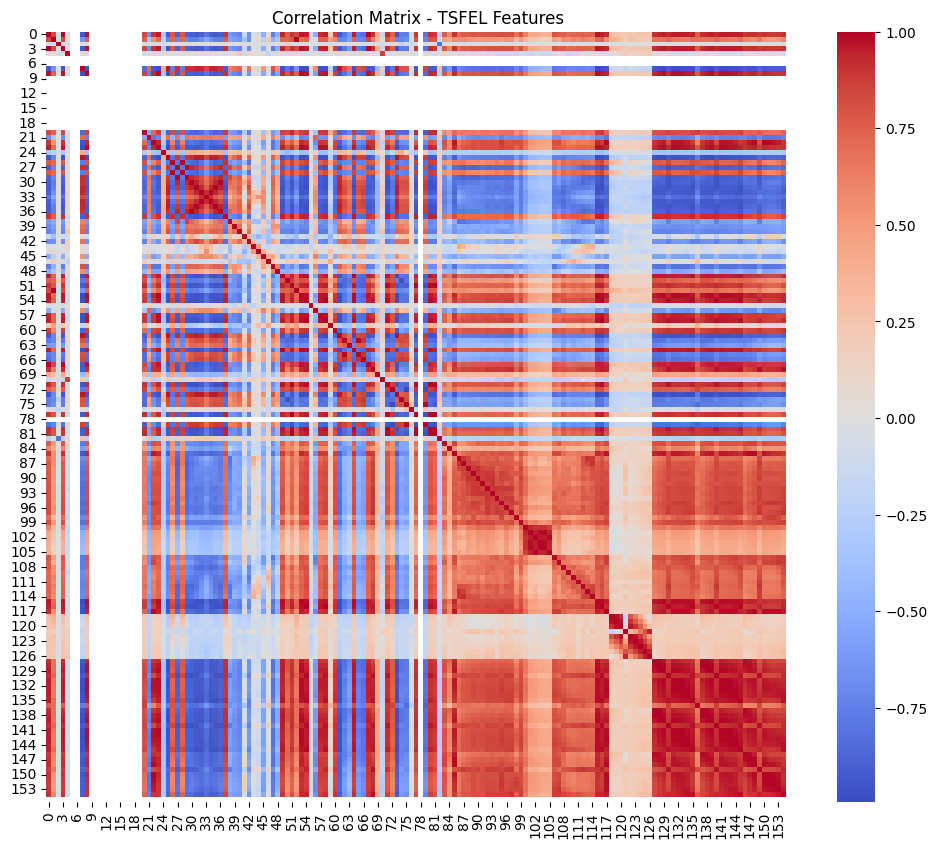

In [ ]:
# Correlation matrix for TSFEL features for total acceleration
ts_features_df = pd.DataFrame(ts_features)
def plot_correlation_matrix(ts_features_df):
    if ts_features_df is not None:
        # some columns are constant and small std columns, causing NaNs in correlation matrix
        corr_tsfel = ts_features_df.corr()
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_tsfel, cmap='coolwarm', center=0)
        plt.title('Correlation Matrix - TSFEL Features')
        plt.show()
    else:
        print('TSFEL features are empty or invalid, cannot plot correlation matrix.')
plot_correlation_matrix(ts_features_df)

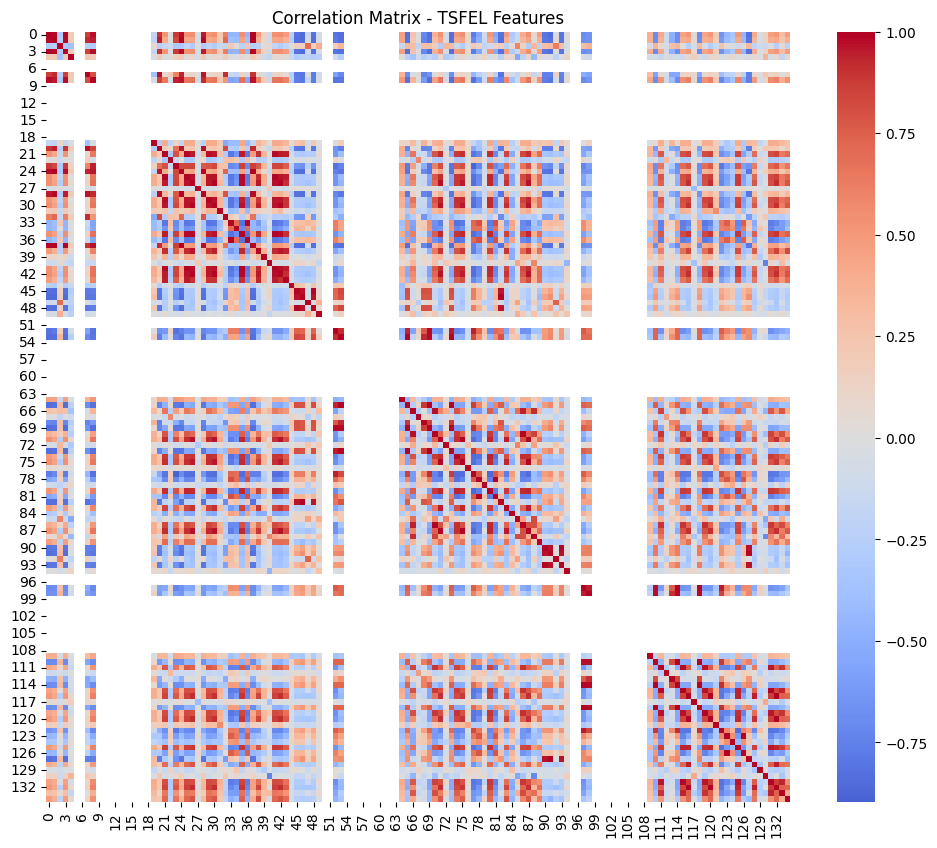

In [26]:
# Correlation matrix for TSFEL features for all three axes combined tsefl features
ts_features_df = pd.DataFrame(ts_features_1)
def plot_correlation_matrix(ts_features_df):
    if ts_features_df is not None:
        # some columns are constant and small std columns, causing NaNs in correlation matrix
        corr_tsfel = ts_features_df.corr()
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_tsfel, cmap='coolwarm', center=0)
        plt.title('Correlation Matrix - TSFEL Features')
        plt.show()
    else:
        print('TSFEL features are empty or invalid, cannot plot correlation matrix.')
plot_correlation_matrix(ts_features_df)

## 7. Finding the redundant features in tsfel features

In [28]:
drop_columns = []
# Features with standard deviation of zero (constant features)
low_std_cols=ts_features_df.columns[ts_features_df.std()<0.001]
low_std_cols

Index([  5,   6,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  27,  40,
        50,  51,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  72,
        85,  95,  96,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
       117, 130],
      dtype='int64')

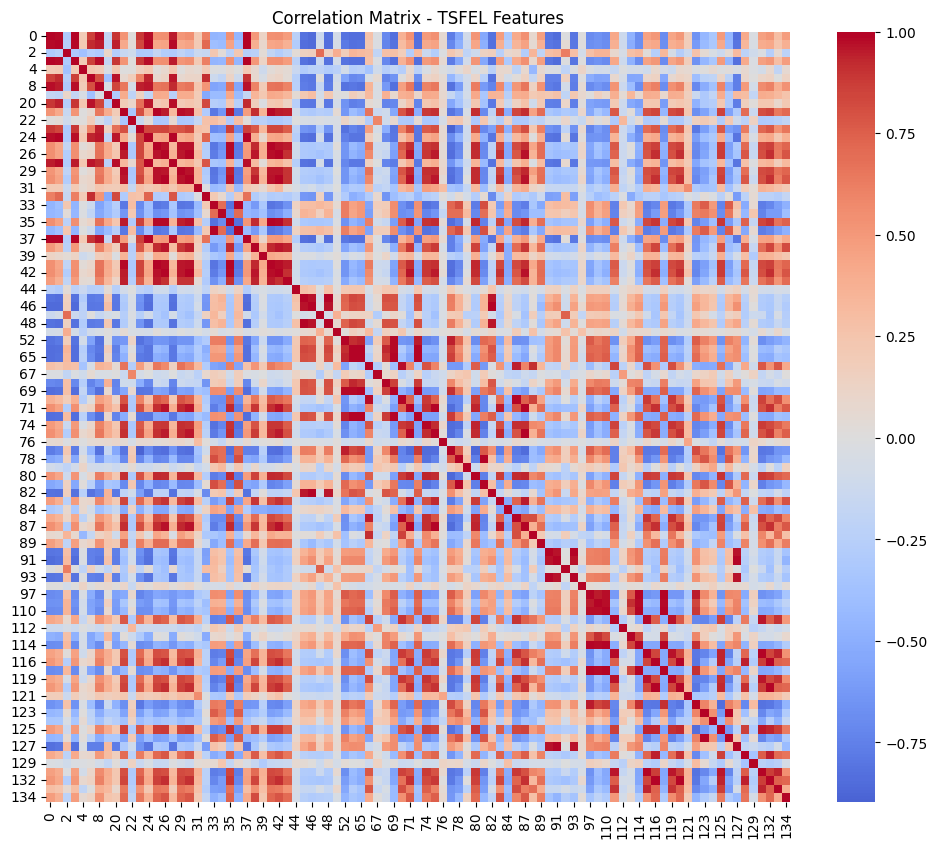

In [29]:
plot_correlation_matrix(ts_features_df.drop(columns=low_std_cols))

In [30]:
## checking for highly correlated features
new_corr=ts_features_df.drop(columns=low_std_cols).corr()
drop_columns = []
for i in range(new_corr.shape[0]):
    for j in range(i):
        if abs(new_corr.iloc[i, j]) > 0.95:
            drop_columns.append(new_corr.columns[i])
            break
print(drop_columns)

[np.int64(1), np.int64(3), np.int64(8), np.int64(20), np.int64(24), np.int64(25), np.int64(26), np.int64(28), np.int64(29), np.int64(30), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(41), np.int64(42), np.int64(43), np.int64(46), np.int64(48), np.int64(65), np.int64(69), np.int64(70), np.int64(71), np.int64(73), np.int64(75), np.int64(81), np.int64(82), np.int64(83), np.int64(86), np.int64(87), np.int64(91), np.int64(93), np.int64(98), np.int64(110), np.int64(114), np.int64(115), np.int64(118), np.int64(119), np.int64(120), np.int64(126), np.int64(127), np.int64(131), np.int64(132)]


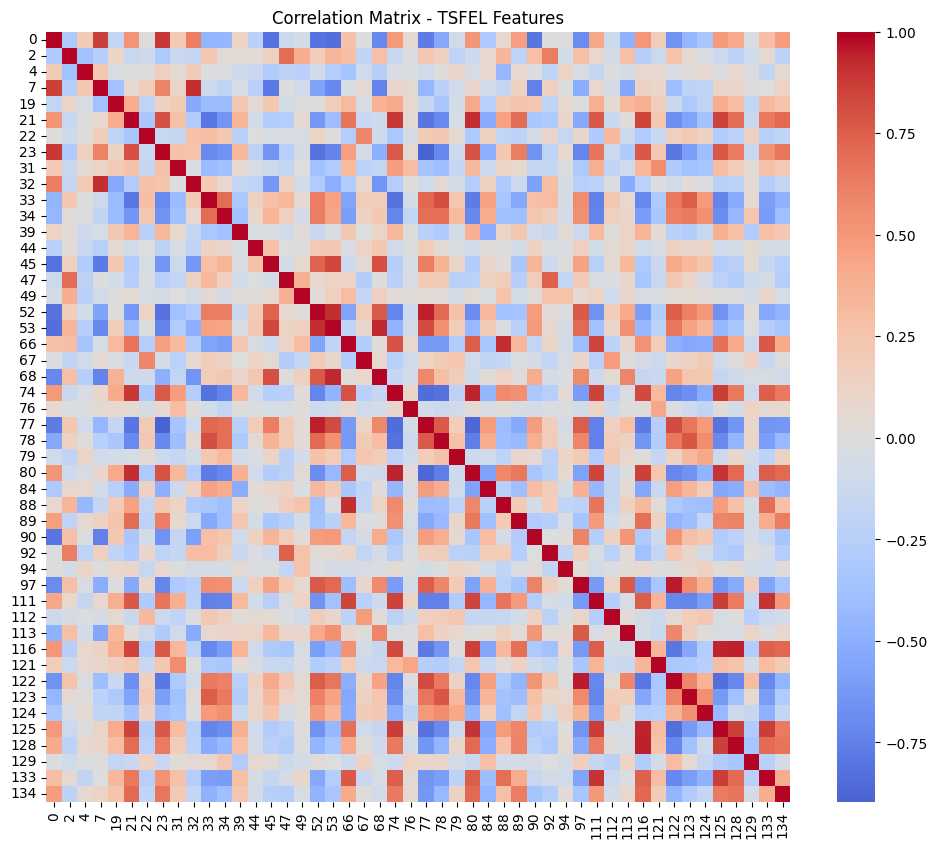

In [31]:
final_ts_features= ts_features_df.drop(columns=drop_columns + list(low_std_cols))
plot_correlation_matrix(final_ts_features)



C:\Users\sun\AppData\Local\Temp\ipykernel_7836\3590594247.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_dataset_features = pd.read_csv(os.path.join("..","human+activity+recognition+using+smartphones","UCI HAR Dataset","train", 'X_train.txt'), delim_whitespace=True, header=None)


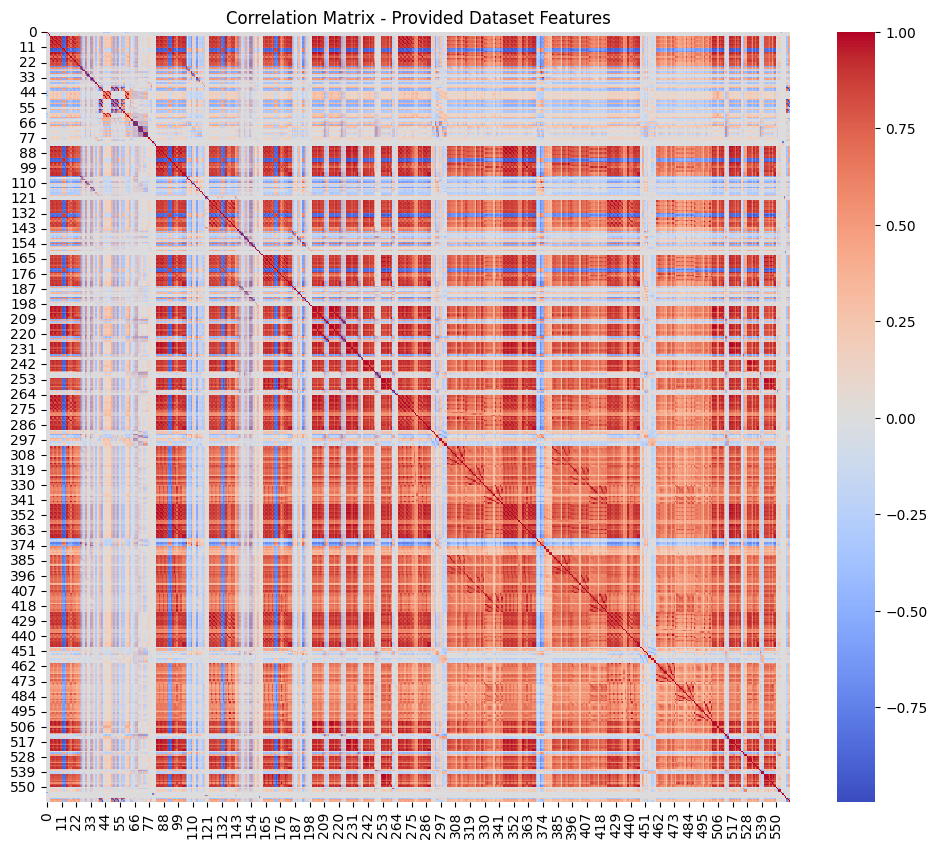

In [13]:
# Load provided dataset features from UCI-HAR Dataset
X_dataset_features = pd.read_csv(os.path.join("..","human+activity+recognition+using+smartphones","UCI HAR Dataset","train", 'X_train.txt'), delim_whitespace=True, header=None)

# Correlation matrix for provided dataset features
if X_dataset_features is not None and X_dataset_features.shape[1] > 0:
    corr_dataset = pd.DataFrame(X_dataset_features).corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_dataset, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix - Provided Dataset Features')
    plt.show()
else:
    print('Provided dataset features are empty or invalid, cannot plot correlation matrix.')


## Extra parts

## 8. FFT Analysis of Acceleration Signals

Perform FFT analysis on the acceleration signals (acc_x, acc_y, acc_z) for each activity class and plot the frequency spectrum.

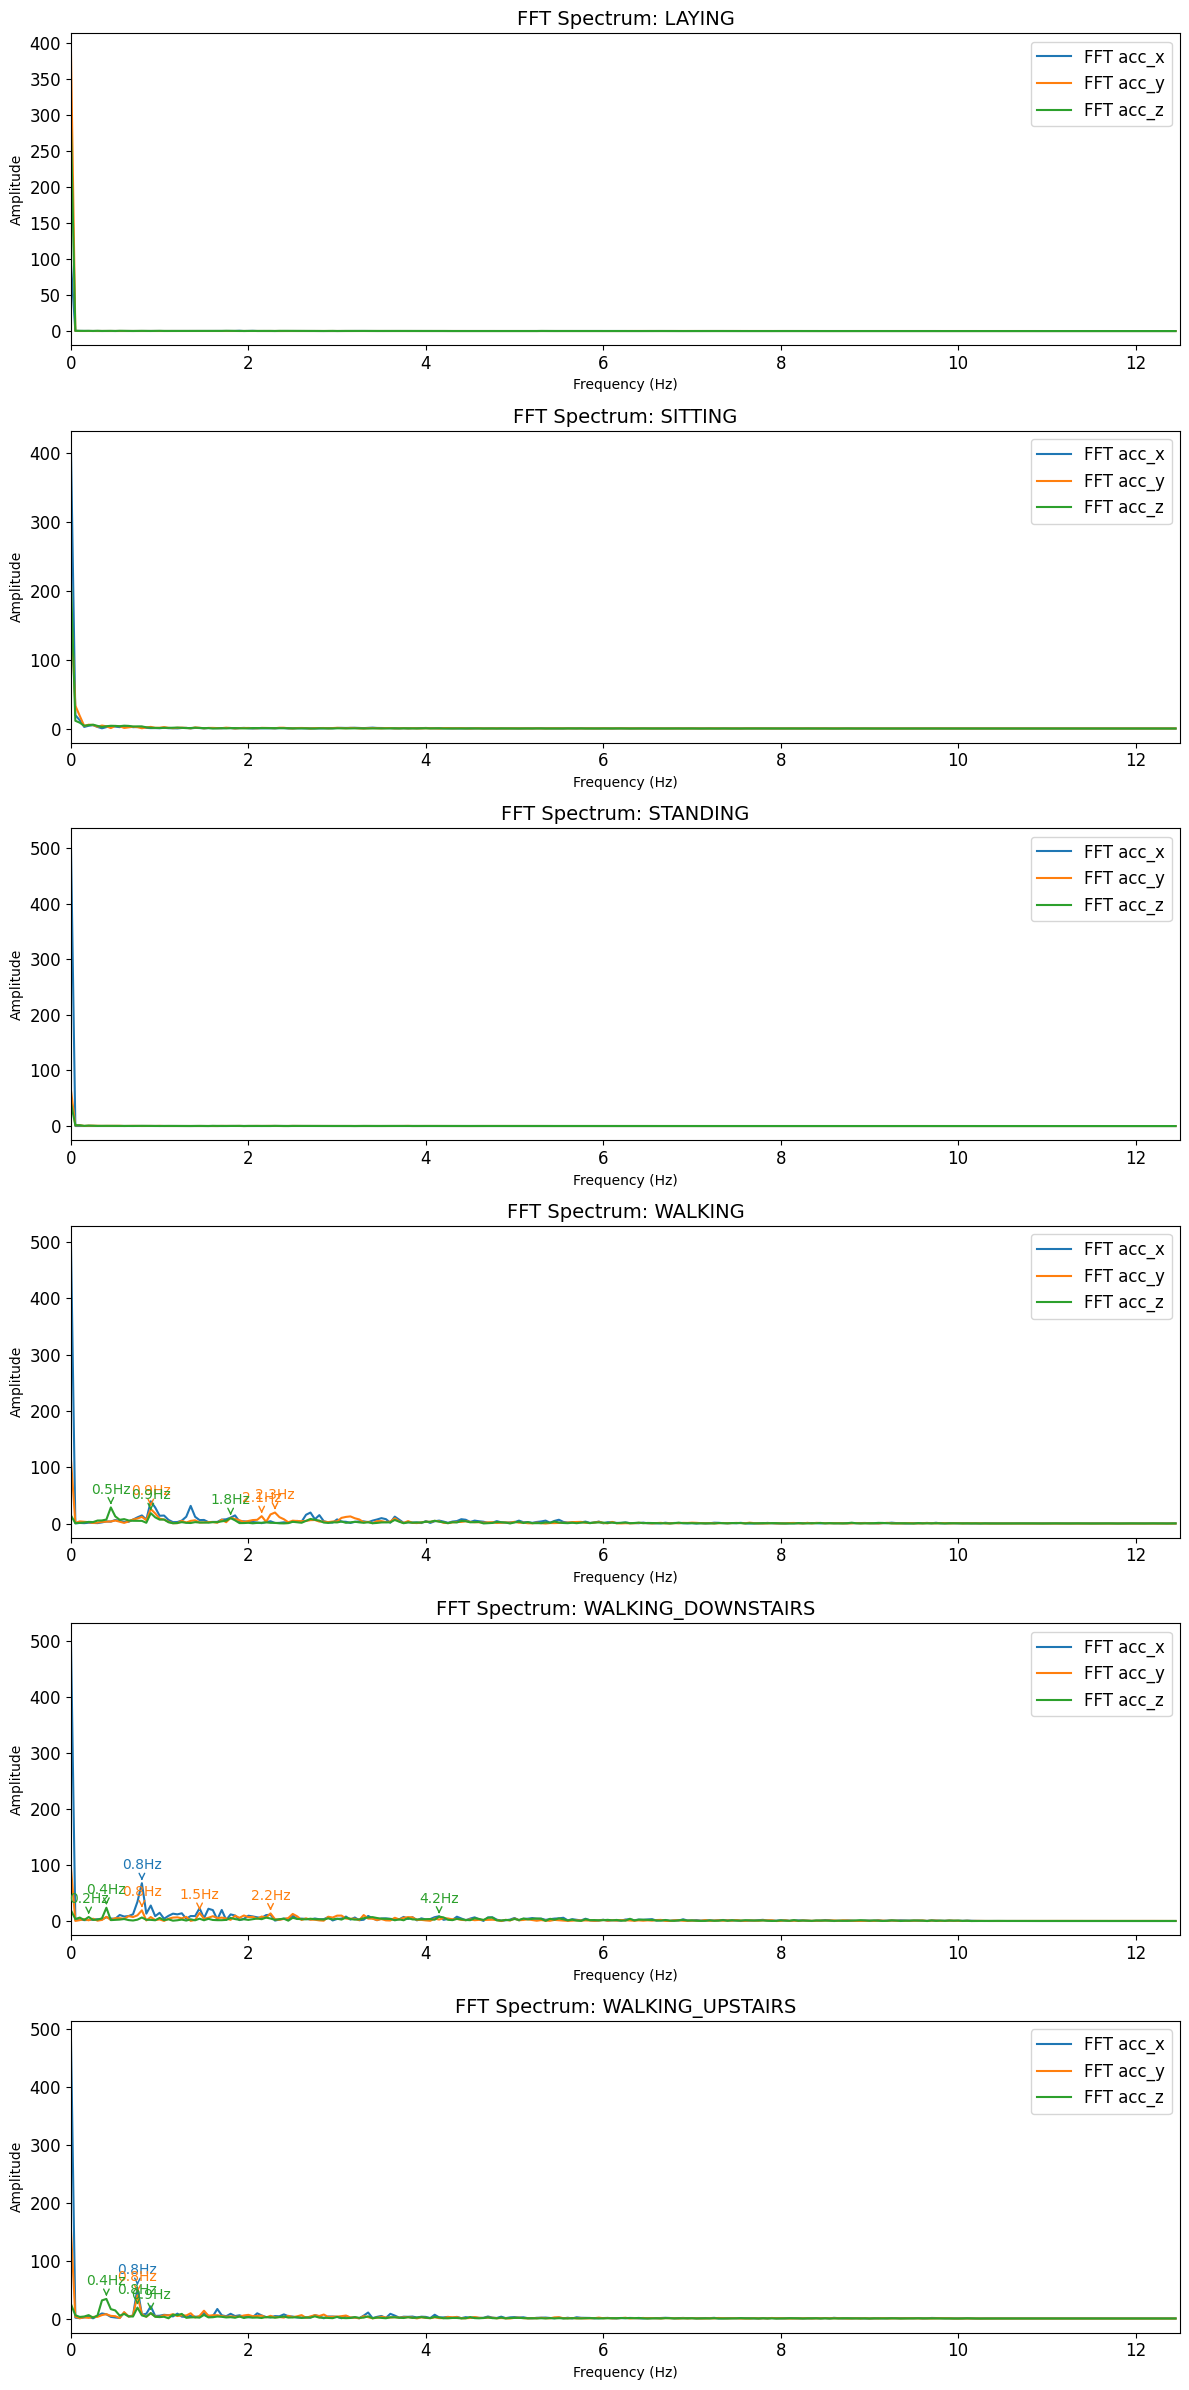

In [14]:
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

sampling_rate = 25  # Hz
n_samples = 500
num_peaks = 3  # Number of peaks to label

activity_classes = df['activity'].unique()
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(12, 4 * len(activity_classes)), sharey=False)
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    sample = df[df['activity'] == activity].iloc[0]
    acc_x = sample['acc_x']
    acc_y = sample['acc_y']
    acc_z = sample['acc_z']

    # FFT for each axis
    f = fftfreq(n_samples, 1/sampling_rate)[:n_samples//2]
    fft_x = np.abs(fft(acc_x))[:n_samples//2]
    fft_y = np.abs(fft(acc_y))[:n_samples//2]
    fft_z = np.abs(fft(acc_z))[:n_samples//2]

    axes[i].plot(f, fft_x, label='FFT acc_x')
    axes[i].plot(f, fft_y, label='FFT acc_y')
    axes[i].plot(f, fft_z, label='FFT acc_z')

    # Find and label peaks for each axis
    for fft_data, axis_label, color in zip([fft_x, fft_y, fft_z], ['acc_x', 'acc_y', 'acc_z'], ['C0', 'C1', 'C2']):
        peaks, _ = find_peaks(fft_data, height=np.max(fft_data)*0.1)
        # Sort peaks by amplitude and select top N
        top_peaks = peaks[np.argsort(fft_data[peaks])[-num_peaks:]] if len(peaks) >= num_peaks else peaks
        for peak in top_peaks:
            axes[i].annotate(f'{f[peak]:.1f}Hz',
                           (f[peak], fft_data[peak]),
                           textcoords="offset points",
                           xytext=(0,10),
                           ha='center',
                           color=color,
                           fontsize=10,
                           arrowprops=dict(arrowstyle='->', color=color))

    axes[i].set_title(f'FFT Spectrum: {activity}', fontsize=14)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(fontsize=12)
    axes[i].tick_params(axis='both', labelsize=12)
    axes[i].set_xlim(0, sampling_rate/2)
plt.tight_layout()
plt.show()

In [107]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
y_train3 = df['activity'].values
tsfeltree = DecisionTreeClassifier(random_state = 42,max_depth=3)
tsfeltree.fit(ts_features_1,y_train3)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [109]:
ts_features_1.shape

(180, 135)

In [110]:
import joblib
joblib.dump(tsfeltree, 'tsfeltree_model_all_axis.joblib')


['tsfeltree_model_all_axis.joblib']

In [112]:
tsfeltree.score(ts_features_1,y_train3)

0.7944444444444444